SETUP


MENTAL HEALTH CLASSIFICATION


In [1]:
import pandas as pd
import string
import re
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv(
    'C:\src\ml_project\MentalHealthClassification.csv'
)

## EXPLORATORY DATA ANALYSIS

In [3]:
df.head(10)

,id,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
5,5,"every break, you must be nervous, like somethi...",Anxiety
6,6,"I feel scared, anxious, what can I do? And may...",Anxiety
7,7,Have you ever felt nervous but didn't know why?,Anxiety
8,8,"I haven't slept well for 2 days, it's like I'm...",Anxiety
9,9,"I'm really worried, I want to cry.",Anxiety


In [4]:
## (Rows , Columns)
df.shape

(53044, 3)

This dataset only has 3 variables id, statement and status. Only 2 variables that are going to  be used,  statement and status. id is only an identifier and will be removed. 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53044 entries, 0 to 53043
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         53044 non-null  object
 1   statement  52681 non-null  object
 2   status     53042 non-null  object
dtypes: object(3)
memory usage: 1.2+ MB


In [6]:
df.describe().T

,count,unique,top,freq
id,53044,53044,0,1
statement,52681,51068,what do you mean?,22
status,53042,7,Normal,16351


In [7]:
df.columns.tolist()

['id', 'statement', 'status']

In [8]:
df.isnull().sum()

id             0
statement    363
status         2
dtype: int64

In [9]:
df.duplicated().sum()

0

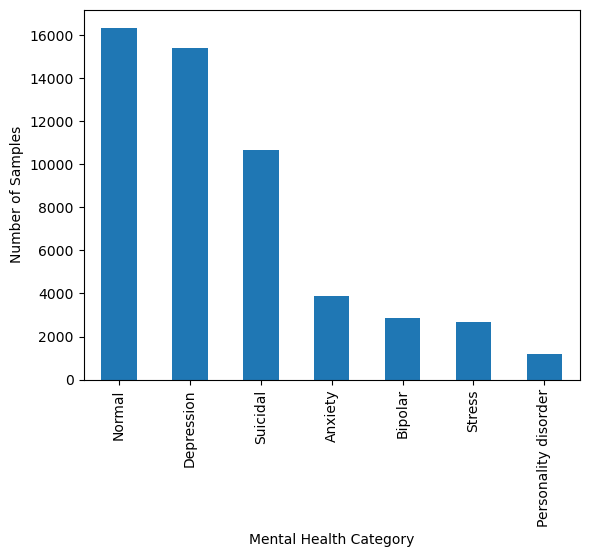

In [10]:
df['status'].value_counts().plot(kind='bar')
plt.xlabel("Mental Health Category")
plt.ylabel("Number of Samples")
plt.show()

Class Imbalance with normal, depression and suicidal ranks among the highest in samples, while anxiety, bipolar, stress and especially personality disorder ranks the lowest. 

This imbalance may result in bias during model training, causing models to favor majority classes over the minority. 

In [11]:
df['status'].value_counts(normalize=True) * 100

status
Normal                  30.826515
Depression              29.041137
Suicidal                20.082199
Anxiety                  7.330040
Bipolar                  5.424004
Stress                   5.031862
Personality disorder     2.264243
Name: proportion, dtype: float64

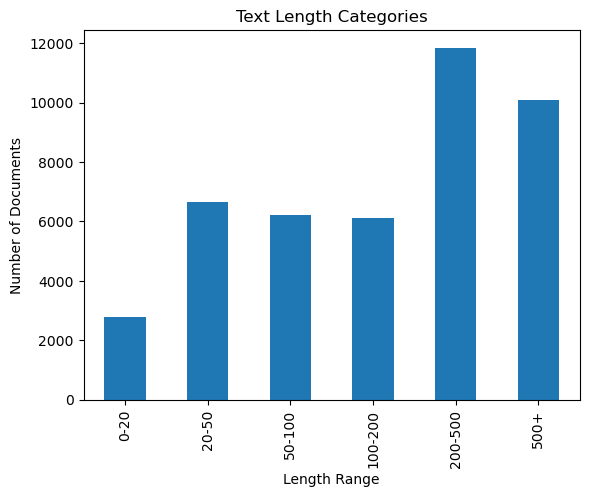

In [12]:
df['text_length'] = df['statement'].astype(str).apply(len)

bins = [0, 20, 50, 100, 200, 500, 1000]
labels = ['0-20','20-50','50-100','100-200','200-500','500+']

df['length_group'] = pd.cut(df['text_length'], bins=bins, labels=labels)

df['length_group'].value_counts().sort_index().plot(kind='bar')
plt.title("Text Length Categories")
plt.xlabel("Length Range")
plt.ylabel("Number of Documents")
plt.show()

In [13]:
df.groupby('status')['text_length'].mean()

status
Anxiety                 760.305041
Bipolar                 919.440737
Depression              844.611724
Normal                   90.761360
Personality disorder    863.971690
Stress                  598.130761
Suicidal                732.007323
Name: text_length, dtype: float64

The dataset contains varying lengths of text length ranging from 0-500. Most samples are around 200-500+ in length.

In [14]:
df['word_count'] = df['statement'].astype(str).apply(lambda x: len(x.split()))
df['word_count'].describe()

count    53044.000000
mean       112.387245
std        163.436739
min          1.000000
25%         15.000000
50%         61.000000
75%        147.250000
max       6300.000000
Name: word_count, dtype: float64

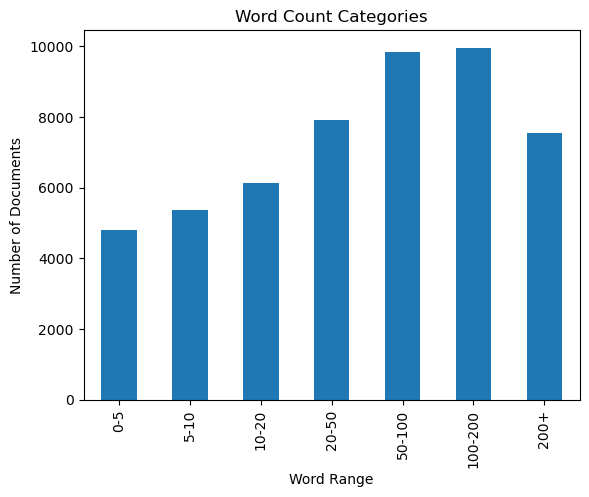

In [15]:
bins = [0, 5, 10, 20, 50, 100, 200, 500]
labels = ['0-5','5-10','10-20','20-50','50-100','100-200','200+']

df['word_group'] = pd.cut(df['word_count'], bins=bins, labels=labels)

df['word_group'].value_counts().sort_index().plot(kind='bar')

plt.title("Word Count Categories")
plt.xlabel("Word Range")
plt.ylabel("Number of Documents")
plt.show()

Most samples contains 50-200 word counts in the dataset. However, a few outliers are spotted with a some that have significantly more word counts than the rest with both being at around 6000+ and 5000+ word counts. Further analysis are done to decide what to do with the outliers.

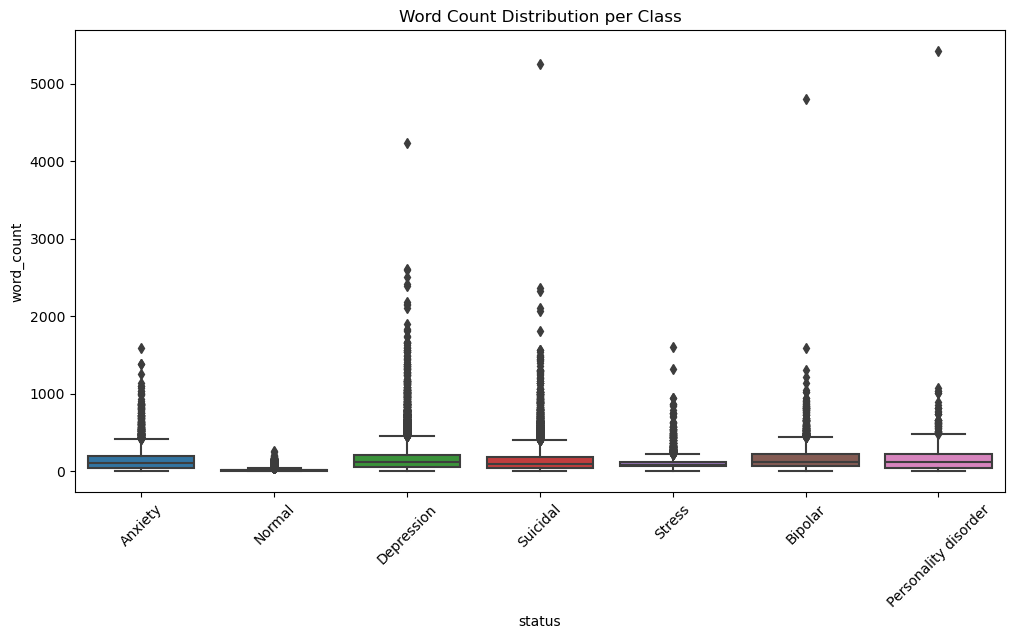

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(x='status', y='word_count', data=df)
plt.xticks(rotation=45)
plt.title("Word Count Distribution per Class")
plt.show()

In [17]:
df[df['word_count'] == df['word_count'].max()]

,id,statement,status,text_length,length_group,word_count,word_group
13293,13293,I cannot TAKE IT ANYMORE. I cannot TAKE IT ANY...,NaN,32759,NaN,6300,NaN


In [18]:
outliers = df[df['word_count'] > 1000]

len(outliers)

209

In [19]:
outliers[['statement', 'word_count', 'status']].head(10)
outliers['status'].value_counts()

status
Depression              121
Suicidal                 60
Anxiety                  11
Bipolar                   8
Personality disorder      6
Stress                    2
Name: count, dtype: int64

In [20]:
df = df[df['word_count'] != df['word_count'].max()] ## Remove the 6000 words
df['word_count'].describe()

count    53043.000000
mean       112.270592
std        161.214894
min          1.000000
25%         15.000000
50%         61.000000
75%        147.000000
max       5419.000000
Name: word_count, dtype: float64

A total of 209 outliers was found. After analysis, 208 outliers with the exception of highest amount are to be kept for training. This is because due to most of it still contains meaningful contents that are useful for model training. The exception however are removed because it is a spam of the same words reaching a total of 6000+ word counts

In [21]:
(df['statement'] == "").sum() #Check Empty Strings

0

In [22]:

df[df['statement'].duplicated(keep=False)].sort_values('statement')


,id,statement,status,text_length,length_group,word_count,word_group
52042,52041,"""Buy Friends"" comment? My mother doesn't have ...",Anxiety,302,200-500,63,50-100
53028,53027,"""Buy Friends"" comment? My mother doesn't have ...",Anxiety,302,200-500,63,50-100
49301,49300,"""Desk Toys for Your Stressful Day!"" \n\nDesk ...",Stress,893,500+,154,100-200
48421,48420,"""Desk Toys for Your Stressful Day!"" \n\nDesk ...",Stress,893,500+,154,100-200
18,18,"""No regrets or grudges/angry at things that ha...",Anxiety,123,100-200,20,10-20
...,...,...,...,...,...,...,...
52839,52838,NaN,Anxiety,3,0-20,1,0-5
52871,52870,NaN,Anxiety,3,0-20,1,0-5
52937,52936,NaN,Anxiety,3,0-20,1,0-5
53011,53010,NaN,Anxiety,3,0-20,1,0-5


# PREPROCESSING

---


  

```
REMOVE MISSING VALUES
REMOVE DUPLICATES
CONVERT TEXT TO LOWERCASE
REMOVE PUNCTUATION
```


```
HANDLE REPEATED CHARACTERS
REMOVE SPECIAL CHARACTERS
```


```
TOKENIZATION
STOPWORD REMOVAL
LEMMETIZATION
STEMMING
```


```
TF-IDF
WORD CLOUD
```




---







In [23]:
df.iloc[290:300]

,id,statement,status,text_length,length_group,word_count,word_group
290,290,"For a long time, my heart feels like it's goin...",Anxiety,75,50-100,15,10-20
291,291,"Now, he's always anxious every day, it feels l...",Anxiety,212,200-500,36,20-50
292,292,The habit of being anxious is clear,Anxiety,35,20-50,7,5-10
293,293,NaN,Anxiety,3,0-20,1,0-5
294,294,sleep but restless. understand?,Anxiety,31,20-50,4,0-5
295,295,"I'm nervous but I don't know why, it's really ...",Anxiety,96,50-100,19,10-20
296,296,"Anjir is so restless today, what's wrong?",Anxiety,41,20-50,7,5-10
297,297,"The restlessness that hit, really disturbs the...",Anxiety,57,50-100,8,5-10
298,298,Shit! I'm addicted to playing cellphones so th...,Anxiety,119,100-200,24,20-50
299,299,"um! Pls, how do I feel afraid to go out of the...",Anxiety,200,100-200,42,20-50


In [24]:
# Drop 'id' columns
df = df.drop('id', axis = 1)
df.iloc[290:300]

,statement,status,text_length,length_group,word_count,word_group
290,"For a long time, my heart feels like it's goin...",Anxiety,75,50-100,15,10-20
291,"Now, he's always anxious every day, it feels l...",Anxiety,212,200-500,36,20-50
292,The habit of being anxious is clear,Anxiety,35,20-50,7,5-10
293,NaN,Anxiety,3,0-20,1,0-5
294,sleep but restless. understand?,Anxiety,31,20-50,4,0-5
295,"I'm nervous but I don't know why, it's really ...",Anxiety,96,50-100,19,10-20
296,"Anjir is so restless today, what's wrong?",Anxiety,41,20-50,7,5-10
297,"The restlessness that hit, really disturbs the...",Anxiety,57,50-100,8,5-10
298,Shit! I'm addicted to playing cellphones so th...,Anxiety,119,100-200,24,20-50
299,"um! Pls, how do I feel afraid to go out of the...",Anxiety,200,100-200,42,20-50


In [25]:
# Drop Empty and duplicate Columns

df = df.dropna(subset=['statement'])
df = df.dropna(subset=['status'])
df = df.drop_duplicates(subset=['statement'])
df.iloc[290:300]

,statement,status,text_length,length_group,word_count,word_group
296,"Anjir is so restless today, what's wrong?",Anxiety,41,20-50,7,5-10
297,"The restlessness that hit, really disturbs the...",Anxiety,57,50-100,8,5-10
298,Shit! I'm addicted to playing cellphones so th...,Anxiety,119,100-200,24,20-50
299,"um! Pls, how do I feel afraid to go out of the...",Anxiety,200,100-200,42,20-50
300,Why are you so nervous :(((,Anxiety,27,20-50,6,5-10
301,It seems like I'm really at the anxiety stage ...,Anxiety,234,200-500,37,20-50
302,"That's if you're worried/worried, the parno is...",Anxiety,59,50-100,10,5-10
303,very nervous,Anxiety,12,0-20,2,0-5
305,hello? buddy it's been a long time since jbjb ...,Anxiety,301,200-500,58,50-100
306,-11fess starts again every night is restless :...,Anxiety,50,20-50,8,5-10


## CONVERT TO LOWER CASE

In [26]:
# Convert to Lowercase
df['clean_text'] = df['statement'].str.lower()
df.sample(10)

,statement,status,text_length,length_group,word_count,word_group,clean_text
6094,"Bored, do you want to rest, can you block ever...",Normal,58,50-100,12,10-20,"bored, do you want to rest, can you block ever..."
52389,It feels impossible to relax I lost my job a w...,Anxiety,262,200-500,51,50-100,it feels impossible to relax i lost my job a w...
27235,Since my dad died I have been sad. I think I h...,Suicidal,610,500+,128,100-200,since my dad died i have been sad. i think i h...
23393,I am just so tired of it. Everything I loved a...,Suicidal,479,200-500,99,50-100,i am just so tired of it. everything i loved a...
50780,Anyone else have trouble verbalizing their tho...,Personality disorder,822,500+,153,100-200,anyone else have trouble verbalizing their tho...
25701,You do not have to but it would mean a lot Hey...,Depression,335,200-500,72,50-100,you do not have to but it would mean a lot hey...
30200,i've actually been pretty good. you?,Normal,36,20-50,6,5-10,i've actually been pretty good. you?
46093,Is it possible to go manic while still on meds...,Bipolar,471,200-500,90,50-100,is it possible to go manic while still on meds...
46153,New Art Subreddit Hi everyone! This morning I ...,Bipolar,260,200-500,43,20-50,new art subreddit hi everyone! this morning i ...
20770,i realised last night that I have been inheren...,Suicidal,5271,NaN,995,NaN,i realised last night that i have been inheren...


## REMOVE URLS

In [27]:

def remove_url(text):
  return re.sub(r'https?://\S+|www\.\S+', '', text)

In [28]:
df['clean_text'] = df['clean_text'].apply(lambda x: remove_url(x))
df.sample(10)

,statement,status,text_length,length_group,word_count,word_group,clean_text
32882,but you're right. there are a lot of fires.,Normal,43,20-50,9,5-10,but you're right. there are a lot of fires.
2411,Omaaayyyyyyyy talagaaa..WE MISS YOU XAVMI,Normal,41,20-50,5,0-5,omaaayyyyyyyy talagaaa..we miss you xavmi
37726,i used to be quite smart aced everything in hi...,Depression,1349,NaN,277,200+,i used to be quite smart aced everything in hi...
45799,Depression Craving Mania a poem by me I try no...,Bipolar,432,200-500,81,50-100,depression craving mania a poem by me i try no...
30991,what's on tv?,Normal,13,0-20,3,0-5,what's on tv?
7814,I am just tired of everything and want to stop...,Depression,299,200-500,56,50-100,i am just tired of everything and want to stop...
50062,SCARED TO BE A PARENT This is me venting? Help...,Bipolar,2292,NaN,427,200+,scared to be a parent this is me venting? help...
8400,If you want to reply with anything diffetent l...,Suicidal,209,200-500,45,20-50,if you want to reply with anything diffetent l...
34016,Cold feeling inside lower abdominal I have thi...,Anxiety,175,100-200,29,20-50,cold feeling inside lower abdominal i have thi...
30867,i'm not being nosey. i'm just asking.,Normal,37,20-50,7,5-10,i'm not being nosey. i'm just asking.


## REMOVE PUNCTUATIONS

In [29]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [30]:
def remove_punctuations(text):
  punctuations = string.punctuation
  return text.translate(str.maketrans('', '', punctuations))

In [31]:
df['clean_text'] = df['clean_text'].apply(lambda x: remove_punctuations(x))
df.sample(10)

,statement,status,text_length,length_group,word_count,word_group,clean_text
23837,I (44/M) had depression and anxiety issues whe...,Depression,1293,NaN,251,200+,i 44m had depression and anxiety issues when i...
5227,lmﾃ｢ﾅ｡ need a blank acc w usn mulchar that goe...,Normal,92,50-100,20,10-20,lmﾃ｢ﾅ｡ need a blank acc w usn mulchar that goe...
30502,you've seen it before?,Normal,23,20-50,4,0-5,youve seen it before
44986,francesdath not bad transitioning being visite...,Normal,117,100-200,19,10-20,francesdath not bad transitioning being visite...
31886,but thieves don't know that.,Normal,28,20-50,5,0-5,but thieves dont know that
23932,So I have been depressed for the past 2 years....,Depression,976,500+,185,100-200,so i have been depressed for the past 2 years ...
32262,"they always make ""what's next"" sound exciting,...",Normal,63,50-100,11,10-20,they always make whats next sound exciting but...
24336,"I am too much of a coward to cut my wrist, jum...",Suicidal,302,200-500,59,50-100,i am too much of a coward to cut my wrist jump...
49809,Coming off Seroquel Okay so around this time l...,Bipolar,1019,NaN,199,100-200,coming off seroquel okay so around this time l...
46393,Motivation to take medication Hey guys! I'm re...,Bipolar,256,200-500,45,20-50,motivation to take medication hey guys im real...


## STOPWORD REMOVALS

In [32]:

from nltk.corpus import stopwords
" , ".join(stopwords.words('english'))

"a , about , above , after , again , against , ain , all , am , an , and , any , are , aren , aren't , as , at , be , because , been , before , being , below , between , both , but , by , can , couldn , couldn't , d , did , didn , didn't , do , does , doesn , doesn't , doing , don , don't , down , during , each , few , for , from , further , had , hadn , hadn't , has , hasn , hasn't , have , haven , haven't , having , he , he'd , he'll , her , here , hers , herself , he's , him , himself , his , how , i , i'd , if , i'll , i'm , in , into , is , isn , isn't , it , it'd , it'll , it's , its , itself , i've , just , ll , m , ma , me , mightn , mightn't , more , most , mustn , mustn't , my , myself , needn , needn't , no , nor , not , now , o , of , off , on , once , only , or , other , our , ours , ourselves , out , over , own , re , s , same , shan , shan't , she , she'd , she'll , she's , should , shouldn , shouldn't , should've , so , some , such , t , than , that , that'll , the , th

In [33]:
STOPWORDS = set(stopwords.words('english'))
def remove_stopwords(text):
  return " ".join([word for word in text.split() if word not in STOPWORDS])

In [34]:
df['clean_text'] = df['clean_text'].apply(lambda x: remove_stopwords(x))
df.sample(10)

,statement,status,text_length,length_group,word_count,word_group,clean_text
44736,kev nz lol better let aboy0 know if he s doing...,Normal,123,100-200,26,20-50,kev nz lol better let aboy0 know deploy 9 0 be...
18801,"Obviously, do not stop helping and supporting ...",Suicidal,656,500+,113,100-200,obviously stop helping supporting people know ...
32690,did you watch that golf tournament?,Normal,35,20-50,6,5-10,watch golf tournament
12882,Almost committed suicide Suicide,Suicidal,32,20-50,4,0-5,almost committed suicide suicide
4402,"If you really have to go to the ICU, it's okay...",Normal,113,100-200,23,20-50,really go icu okay important thing get better ...
52077,Looking for perspective I (F18) have been give...,Anxiety,1520,NaN,277,200+,looking perspective f18 given diagnosis gad ge...
27937,I beg him to let go of me so I can get my phon...,Stress,476,200-500,97,50-100,beg let go get phone call dad bang floor screa...
8884,on paper my life is good and i will acknowledg...,Depression,560,500+,111,100-200,paper life good acknowledge lost willpower try...
17017,I (19M) have been struggling with myself for a...,Depression,689,500+,147,100-200,19m struggling even feel like real person even...
15677,I think about my life. I feel bad. I think abo...,Depression,542,500+,108,100-200,think life feel bad think fact remember feelin...


## REMOVE SPECIAL CHARACTERS

In [35]:
def remove_spl_chars(text):
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

In [36]:
df['clean_text'] = df['clean_text'].apply(lambda x: remove_spl_chars(x))
df.iloc[120:130]

,statement,status,text_length,length_group,word_count,word_group,clean_text
121,restless restlessness haunts self,Anxiety,33,20-50,4,0-5,restless restlessness haunts self
122,The peak period of my stress has passed and I ...,Anxiety,290,200-500,55,50-100,peak period stress passed noisy going friends ...
123,I'm most worried when my mom is sick.,Anxiety,37,20-50,8,5-10,im worried mom sick
124,don't worry yet :),Anxiety,18,0-20,4,0-5,dont worry yet
125,"""Yesterday, I was worried half to death, now m...",Anxiety,102,100-200,19,10-20,yesterday worried half death wife aware stiff
126,The last time I felt this nervous was on Wedne...,Anxiety,119,100-200,24,20-50,last time felt nervous wednesday found mother ...
127,I don't know how many years it took me to jump...,Anxiety,100,50-100,21,20-50,dont know many years took jump could feel desc...
128,"I want to ask, have you ever been worried abou...",Anxiety,231,200-500,48,20-50,want ask ever worried things like even really ...
129,"However, every time I picket, I'm always nervo...",Anxiety,114,100-200,19,10-20,however every time picket im always nervous ev...
130,BY GOD I'M STILL WORRY.,Anxiety,23,20-50,5,0-5,god im still worry


## STEMMING/LEMMETIZATION

In [37]:
# STEMMING
'''
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
def stem_words(text):
  return " ".join([ps.stem(word) for word in text.split()])
  '''

'\nfrom nltk.stem.porter import PorterStemmer\nps = PorterStemmer()\ndef stem_words(text):\n  return " ".join([ps.stem(word) for word in text.split()])\n  '

In [38]:
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

lemmetizer = WordNetLemmatizer()
wordnet_map = {"N":wordnet.NOUN, "V": wordnet.VERB, "J": wordnet.ADJ, "R": wordnet.ADV}

def lemmatize_words(text):
  # find pos tags
  pos_text = pos_tag(text.split())
  return " ".join([lemmetizer.lemmatize(word, wordnet_map.get(pos[0], wordnet.NOUN)) for word, pos in pos_text])

In [39]:
df['clean_text'] = df['clean_text'].apply(lambda x: lemmatize_words(x))
df.sample(10)

,statement,status,text_length,length_group,word_count,word_group,clean_text
46488,Ability What can you tell me about it? I was r...,Bipolar,154,100-200,28,20-50,ability tell recently prescribe first time sta...
46439,Lost my job I don't know if my bipolar shit wa...,Bipolar,340,200-500,66,50-100,lose job dont know bipolar shit part say wasnt...
16816,"there is something that makes me depressed, bu...",Depression,435,200-500,81,50-100,something make depressed order change would ea...
18254,How can you be the friend nobody cares about b...,Suicidal,680,500+,135,100-200,friend nobody care also person everyone call n...
34490,Worried about tetanus??? I was sorting through...,Anxiety,397,200-500,80,50-100,worried tetanus sort ton change really rusty o...
1566,"""I'm proud to be married to you."" I said when ...",Normal,66,50-100,14,10-20,im proud marry say expect koco
15809,I am going into 8th grade and I am sick and ti...,Suicidal,337,200-500,68,50-100,go 8th grade sick tire fucking girl hat nothin...
42687,seattle is in tent i miss my t o peepz tho,Normal,42,20-50,11,10-20,seattle tent miss peepz tho
44743,catvix i am news to me and sorry to hear about...,Normal,54,50-100,13,10-20,catvix news sorry hear job
877,"And if he asks for time to himself, don't be b...",Normal,186,100-200,35,20-50,asks time dont ban give impression leave unila...


Lemmetization was used over Stemming in order to produce more accurate and meaningful words. This technique also takes context into account when converting words. 

While more complex thus more computational resources needed and longer to execute compared to Stemming, the trade off is worth it to achieve the best possible result in text analysis.

## VISUALIZATION

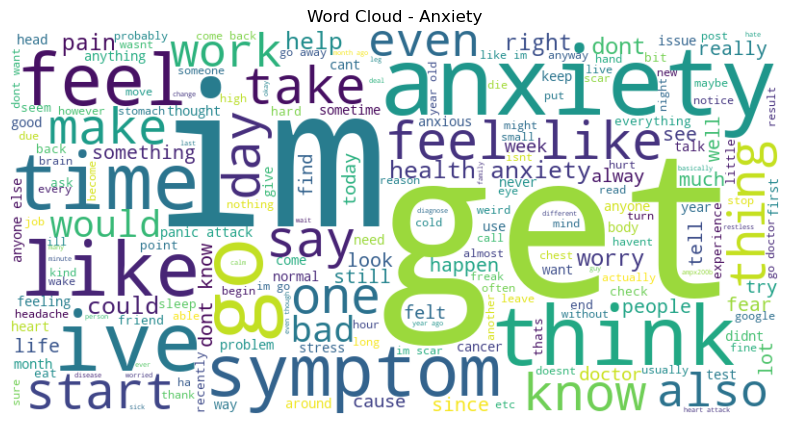

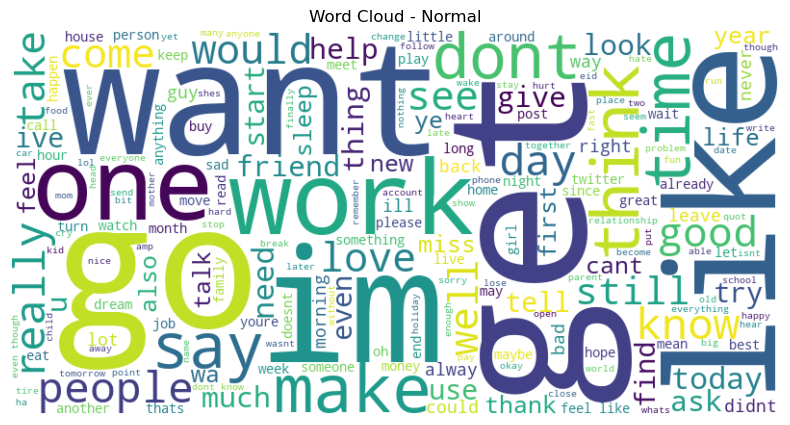

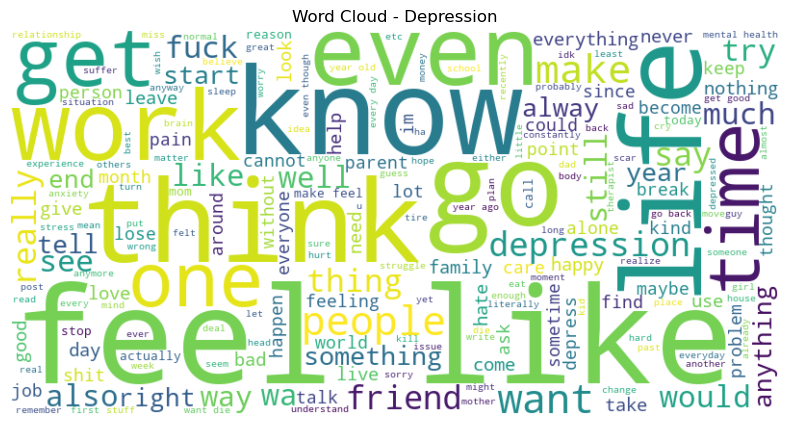

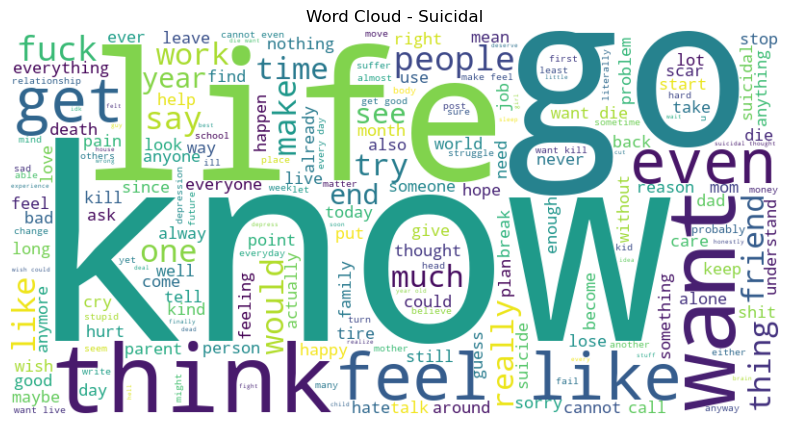

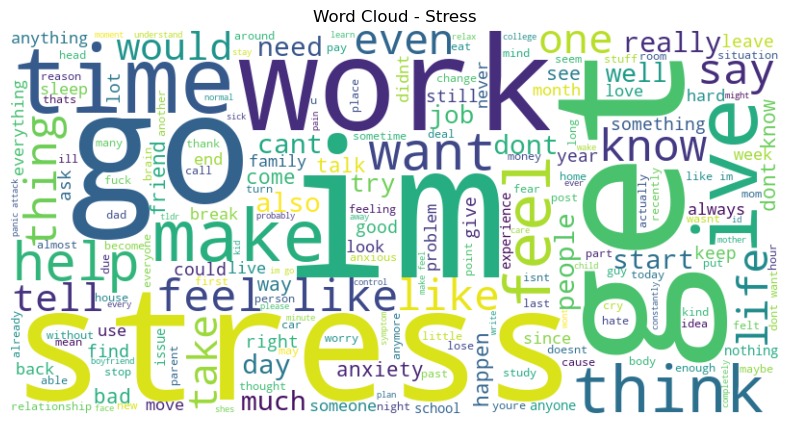

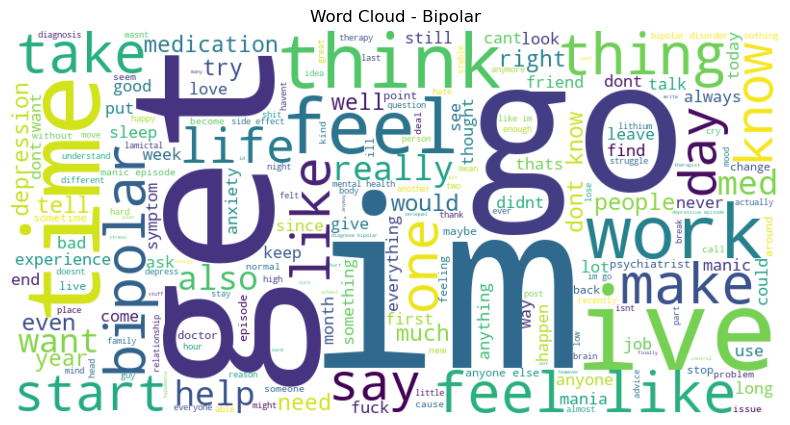

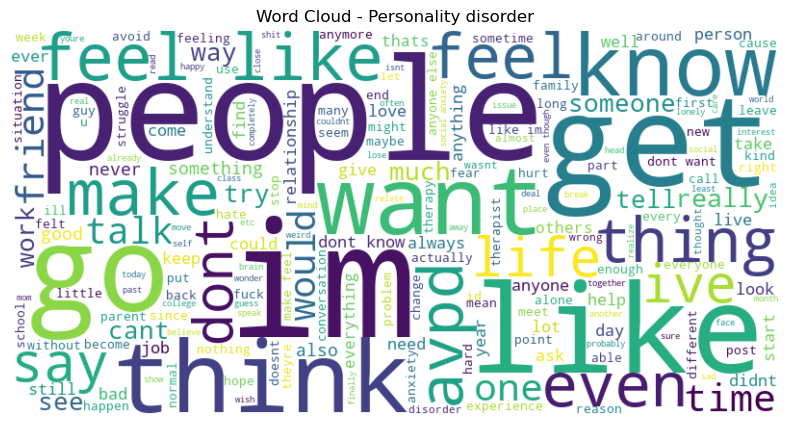

In [40]:
stop_words = set(STOPWORDS)
classes = df['status'].dropna().unique()

for c in classes:
    text = " ".join(df[df['status'] == c]['clean_text'].astype(str))

    wc = WordCloud(
        background_color='white',
        width=800,
        height=400,
        max_words=200,
        stopwords=stop_words
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud - {c}")
    plt.show()

Word Clouds were generated for each classes to gain determine most frequently used words for every classes. This helps understanding which common words are commonly associated with mental health conditions

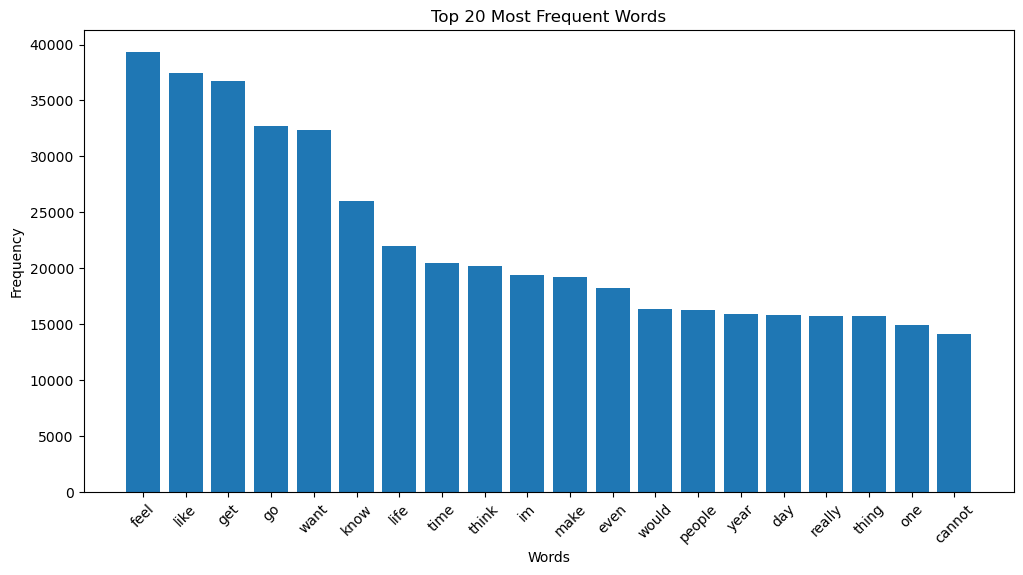

In [41]:
vec = CountVectorizer(max_features=20)
X = vec.fit_transform(df['clean_text'])

words = vec.get_feature_names_out()
counts = X.toarray().sum(axis=0)

sorted_idx = counts.argsort()[::-1]
words = words[sorted_idx]
counts = counts[sorted_idx]

plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

Top 20 most frequent words were gathered to determine dominant vocabulary in the dataset. Many of these words (go, get, go, make, etc) are too general and may not carry any strong meanings to be used for classification. 

## TF-IDF

In [42]:
cust_stopwords = {"im", "ive", "dont", "cant", "wont", "get", "go", "make", "one"}

Before feature extraction, a second stopwords is created to remove generic words that may not play a singificant role or context for the analysis

In [43]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    max_features=20000,
    stop_words=list(cust_stopwords)
)
X = tfidf.fit_transform(df['clean_text'])
y = df['status']

A few parameters was set to address the nature of the dataset. 

ngram_range=(1,2)
    Allows model to include unigrams and bigrams to preserve as much context as possible such as 'feel stress' or 'no hope'.

min_df=2
    set min document frequency to remove words that only appears in 1 document as the  words may be typos or noise. While unlikely, there is still a posibility that it could still potentially remove actual rare words.

max_df = 0.9
    Removes words that are too frequent that appears in almost every document as they may provide litle value for classification. 

max_features = 20000,
    The amount of features after tf-idf + ngram_range increased exponentially
    to around +200000k. Reducing the features is needed to reduce training time and memory usage due to hardware limitations.

In [44]:
print(X.shape) ## (texts, features)

(51067, 20000)


# MODEL



```
LINEAR SUPPORT VECTOR MACHINE
MULTINOMIAL NAIVE BAYES
GRADIENT BOOSTING
LOGISTIC REGRESSION MULTILNOMIAL
NOT FINAL, BOLEH TUKAR
```



## TRAIN/TEST SPLIT

In [45]:
print(df['clean_text'].isna().sum())

0


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 13,
    stratify = y
)

In [47]:
print(X_train.shape)
print(y_test.shape)
print(y_train.shape)
print(X_test.shape)

(40853, 20000)
(10214,)
(40853,)
(10214, 20000)


In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)

print("\nRandom Forest Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Performance:
Accuracy: 0.6720187977286078

Confusion Matrix:
[[ 374    2  249   87    0    0   11]
 [   8  143  295   44    0    0   10]
 [  24    3 2401  230    0    1  358]
 [   7    1  156 3011    2    0   31]
 [   1    0  145   24    6    0    3]
 [  16    1  307   99    0   19   17]
 [   0    1  989  228    0    0  910]]

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.87      0.52      0.65       723
             Bipolar       0.95      0.29      0.44       500
          Depression       0.53      0.80      0.64      3017
              Normal       0.81      0.94      0.87      3208
Personality disorder       0.75      0.03      0.06       179
              Stress       0.95      0.04      0.08       459
            Suicidal       0.68      0.43      0.52      2128

            accuracy                           0.67     10214
           macro avg       0.79      0.43      0.47     10214
        wei

## 1. LOGISTIC REGRESSION

In [ ]:
## LR Balanced 
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=13,
    class_weight='balanced'
)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

multi_class='multinomial'
    This dataset have 7 classes therefore, a multinomial LR is used/

solver='lbfgs'
    A default solver that works well for many problems

class_weight = 'balanced'
    Adjusts each class to be weighted equally to address the imbalance from earlier analysis

In [52]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.745545329939299

Classification Report:

                      precision    recall  f1-score   support

             Anxiety       0.76      0.82      0.79       723
             Bipolar       0.74      0.80      0.77       500
          Depression       0.77      0.60      0.68      3017
              Normal       0.87      0.91      0.89      3208
Personality disorder       0.52      0.72      0.60       179
              Stress       0.45      0.66      0.53       459
            Suicidal       0.65      0.69      0.67      2128

            accuracy                           0.75     10214
           macro avg       0.68      0.74      0.70     10214
        weighted avg       0.75      0.75      0.75     10214


Confusion Matrix:

[[ 593   12   17   39   12   44    6]
 [  13  402   27   17    4   25   12]
 [  88   85 1818  161   59  115  691]
 [  29   12   48 2912   14  132   61]
 [   2    6   12   15  128   11    5]
 [  52   14   28   31   15  304 

The model achieved an accuracy of 0.746, a good performance, but due to class imbalance it may be miselading. 

Based on the F1 scores all classes are doing well, although stress and personality disorder which is at 0.53 andd 0.60 respectively means that the model did not accurately identify these classes as much. This is due to these classes are in the minority and much more difficult to distinguish due to its complex mental health statements.

Macro F1 shows a score of 0.70 showing that overall performance is good and its gap with weighted average shows that small bias between majority and minority classes.

In [53]:
# K-CROSS FOLD VALIDATION

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg'],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000]
}

lr_grid = LogisticRegression(
    multi_class='multinomial',
    random_state=13
)

grid_search = GridSearchCV(
    lr_grid,
    param_grid,
    cv=5,
    scoring='f1_macro', # Imbalanced class 
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)
lr_best = grid_search.best_estimator_

y_pred_best = lr_best.predict(X_test)
y_pred_proba_best = lr_best.predict_proba(X_test)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 1, 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'lbfgs'}
Best CV Score: 0.6875796640859232


param_grid
    C parameter controls regularization strength to prevent overfitting and underfitting
    solver
    lbfgs and newton-cg was used to determine the best optimization algorithm between the two

GridSearchCV
    evaluate different hyperparameter combinations, training data wsa divided into 5 subsets and the model was trained and validated 5 times. f1 macro scoring was selected over accuracy to address the imbalanced classes. 

n_jobs=-1
    This parameter allows all available CPU cores to be used. 

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Accuracy: 0.745545329939299
[[ 593   12   17   39   12   44    6]
 [  13  402   27   17    4   25   12]
 [  88   85 1818  161   59  115  691]
 [  29   12   48 2912   14  132   61]
 [   2    6   12   15  128   11    5]
 [  52   14   28   31   15  304   15]
 [   7   14  417  170   15   47 1458]]
                      precision    recall  f1-score   support

             Anxiety       0.76      0.82      0.79       723
             Bipolar       0.74      0.80      0.77       500
          Depression       0.77      0.60      0.68      3017
              Normal       0.87      0.91      0.89      3208
Personality disorder       0.52      0.72      0.60       179
              Stress       0.45      0.66      0.53       459
            Suicidal       0.65      0.69      0.67      2128

            accuracy                           0.75     10214
           macro avg       0.68      0.74      0.70     10214
        weighted avg       0.75      0.75      0.75     10214



Based on the best model through GridSearchCV, the model has achieved an accuracy score of 0.745, macro f1 of 0.70 and weighted f1 of 0.75. 

Compared to the former Linear Regression model performance, the results are identical. Therefore, it is shown that initial parameters was close to optimal and the best performamce among other tested parameter combinations.

## 2. LINEAR SUPPORT VECTOR MODEL

In [55]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight='balanced',
    random_state=13
)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

LinearSVC was chosen because it can scale better on large number of samples and non-linear decision boundaries.

In [56]:
print("\nLinear SVM Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


Linear SVM Performance:
Accuracy: 0.7394752300763657

Confusion Matrix:
[[ 580   14   29   50   10   36    4]
 [  13  377   51   20    2   22   15]
 [  94   61 1932  173   33   83  641]
 [  28   13   52 2981    6   69   59]
 [   4   11   24   21  102    9    8]
 [  56   12   58   62    6  238   27]
 [  11   16  544  162   13   39 1343]]

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.74      0.80      0.77       723
             Bipolar       0.75      0.75      0.75       500
          Depression       0.72      0.64      0.68      3017
              Normal       0.86      0.93      0.89      3208
Personality disorder       0.59      0.57      0.58       179
              Stress       0.48      0.52      0.50       459
            Suicidal       0.64      0.63      0.64      2128

            accuracy                           0.74     10214
           macro avg       0.68      0.69      0.69     10214
        weight

The model achieved an accuracy of 0.739 , macro f1 of 0.69 and weighted F1 of 0.74.

the overall performance of the model is good. However, similar to Logistic Regression, the models also struggles to classify Stress and Personality Disorder classes with both f\F1 scores only at 0.50 and 0.58 respectively. 

Based on the Weighted F1 score 0f 0.74, the model performs well on majority classes. Macro F1 on the other hand performs slightly worse than Logistic Regression with a score of 0.69 which indicates weaker performance on minority classes. 

The difference between Weighted and Macro F1 indicates that there are small biases toward majority classes.

In [57]:
## K CROSS

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced'],
}

svm = LinearSVC(random_state=13)

grid_svm = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring = 'f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_svm.fit(X_train, y_train)
svm_best = grid_svm.best_estimator_
y_pred_svm = svm_best.predict(X_test)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [58]:
print("\nLinear SVM (GridSearch + 5-Fold CV)")
print("Best Parameters:", grid_svm.best_params_)
print("Best CV Score:", grid_svm.best_score_)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


Linear SVM (GridSearch + 5-Fold CV)
Best Parameters: {'C': 0.1, 'class_weight': 'balanced'}
Best CV Score: 0.6896725692233314

Test Accuracy: 0.7486782847072645

Confusion Matrix:
 [[ 599   10   20   53   12   25    4]
 [  18  392   32   24    4   18   12]
 [  90   61 1883  234   51   79  619]
 [  29    7   36 3009   13   74   40]
 [   3    6   21   18  118   10    3]
 [  54   13   39   58   13  268   14]
 [  15   16  441  220   19   39 1378]]

Classification Report:
                       precision    recall  f1-score   support

             Anxiety       0.74      0.83      0.78       723
             Bipolar       0.78      0.78      0.78       500
          Depression       0.76      0.62      0.69      3017
              Normal       0.83      0.94      0.88      3208
Personality disorder       0.51      0.66      0.58       179
              Stress       0.52      0.58      0.55       459
            Suicidal       0.67      0.65      0.66      2128

            accuracy        

Based on the best model by GridSearchCV, the model achieved an accuracy of 0.747, Macro F1 of 0.70 and Weighted F1 of 0.74. 

Compared to the initial SVCLinear model performance , this model achieved slightly higher performance. The improvement in Macro F1 indicates a slightly more balanced classification among the classes. 

## 3. MULTINOMIAL NAIVE BAYES

In [59]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

Multinomial Naive Bayes is suitable for text classification as it is designed for discrete data. This model is an appropriate choice for this project to classify mental health based on text input.

In [60]:
print("\nMultinomial Naive Bayes Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))


Multinomial Naive Bayes Performance:
Accuracy: 0.6547875465047973

Confusion Matrix:
[[ 398    2  211  108    0    0    4]
 [  13  132  287   60    0    0    8]
 [  33    6 2444  144    0    0  390]
 [   8    0  515 2619    0    0   66]
 [   0    0  154   21    2    0    2]
 [  30    1  301  109    0    8   10]
 [   1    1  927  114    0    0 1085]]

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.82      0.55      0.66       723
             Bipolar       0.93      0.26      0.41       500
          Depression       0.51      0.81      0.62      3017
              Normal       0.82      0.82      0.82      3208
Personality disorder       1.00      0.01      0.02       179
              Stress       1.00      0.02      0.03       459
            Suicidal       0.69      0.51      0.59      2128

            accuracy                           0.65     10214
           macro avg       0.83      0.43      0.45     10214
 

The model achieved an accuracy of 0.655, Macro F1 of 0.45 and Weighted F1 of 0.63

Compared to the previous models, this model achieved the worst performance. Two classes in particular, Stress and Personality Disorder with only 0.03 and 0.02 F1 Scores respectively, shown that the model performs very poorly. Other classes performances are also lower  such as Bipolar and Suicidal.

The large gap between F1 Weighted and F1 Macro shows that this model is very biased towards the majority classes performing well on classes such as Normal and Depression but failing to generalize on minority classes. 



In [61]:
# K FOLD

param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
}

nb = MultinomialNB()

grid_nb = GridSearchCV(
    nb,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_nb.fit(X_train, y_train)

nb_best = grid_nb.best_estimator_

y_pred_nb = nb_best.predict(X_test)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [62]:
print("\nNaive Bayes Performance:")
print("Best Params:", grid_nb.best_params_)
print("Best CV Score:", grid_nb.best_score_)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


Naive Bayes Performance:
Best Params: {'alpha': 0.1}
Best CV Score: 0.5800118798291856

Test Accuracy: 0.6873898570589387
                      precision    recall  f1-score   support

             Anxiety       0.72      0.70      0.71       723
             Bipolar       0.78      0.58      0.66       500
          Depression       0.55      0.75      0.64      3017
              Normal       0.87      0.82      0.84      3208
Personality disorder       1.00      0.16      0.27       179
              Stress       0.63      0.17      0.27       459
            Suicidal       0.66      0.58      0.62      2128

            accuracy                           0.69     10214
           macro avg       0.74      0.54      0.57     10214
        weighted avg       0.71      0.69      0.68     10214



Based on the best model by GridSearchCV, This model performs significantly better than the initial model but its performance still remains among the lowest. The model achieved an accuracy of 0.687, Macro F1 of 0.57 and Weighted F1 of 0.68

While Stress and Personality Disorder classes  improved, it still performs poorly with an F1 score of 0.27 as the model still struggles to handle minority classes.

While the difference between Macro F1 and Weighted F1 while improved thanks to tuning, it still indicates that the model sill struggle to generalize on minority classes. 

In [69]:
data = {
    "Model": [
        "Logistic Regression",
        "Logistic Regression (GridSearch)",
        "Linear SVM",
        "Linear SVM (GridSearch)",
        "Naive Bayes",
        "Naive Bayes (Tuned)"
    ],
    "Accuracy": [
        0.745,
        0.745,
        0.739,
        0.749,
        0.655,
        0.687
    ],
    "Macro F1": [
        0.70,
        0.70,
        0.69,
        0.70,
        0.45,
        0.57
    ],
    "Weighted F1": [
        0.75,
        0.75,
        0.74,
        0.74,
        0.63,
        0.68
    ]
}

df_results = pd.DataFrame(data)
df_results.sort_values(by="Macro F1", ascending=False)

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.745,0.70,0.75
1,Logistic Regression (GridSearch),0.745,0.70,0.75
3,Linear SVM (GridSearch),0.749,0.70,0.74
2,Linear SVM,0.739,0.69,0.74
5,Naive Bayes (Tuned),0.687,0.57,0.68
4,Naive Bayes,0.655,0.45,0.63


From the table above, Logistic Regression and Linear SVM(GridSearch) performances are almost similar only differences in Weighted F1 indicating that Logistic Regression performs slightly better for majority classes .

While LinearSVM achieved the highest accuracy of 0.749 while Logistic Regression only achieved 0.745, accuracy is not a reliable indicator due to the class imbalance in the dataset.

Naive Bayes however performs the worst compared to other models, especially in Macro F1 score due to its poor performance on minority classes.

Overall, the champion model for this project is Logistic Regression due to its high Macro F1 and Weighted F1 scores.  

In [ ]:
# FEATURE IMPORTANCE

feature_names = tfidf.get_feature_names_out()
classes = lr_best.classes_ 

for i, class_name in enumerate(classes):
    top_indices = np.argsort(lr_best.coef_[i])[-10:] 

    print(f"\nTop words for class: {class_name}")
    print([feature_names[j] for j in top_indices])


Top words for class: Anxiety
['heart', 'it', 'restlessness', 'cancer', 'worried', 'nervous', 'worry', 'anxious', 'restless', 'anxiety']

Top words for class: Bipolar
['stable', 'latuda', 'lithium', 'hypomanic', 'lamictal', 'mania', 'med', 'episode', 'manic', 'bipolar']

Top words for class: Depression
['pression', 'antidepressant', 'life', 'doe', 'ha', 'depressed', 'depress', 'cannot', 'wa', 'depression']

Top words for class: Normal
['ptsd', 'holiday', 'quot', 'didnt', 'eid', 'yes', 'ha', 'twitter', 'url', 'wa']

Top words for class: Personality disorder
['avoidance', 'relate', 'view poll', 'poll', 'didnt', 'social', 'people', 'avoidant', 'avoid', 'avpd']

Top words for class: Stress
['boyfriend', 'flashback', 'pay', 'anxiety', 'homeless', 'relax', 'abuse', 'ptsd', 'tldr', 'stress']

Top words for class: Suicidal
['goodbye', 'life', 'rt', 'end', 'fuck', 'die', 'suicidal', 'suicide', 'kill', 'cannot']


Feature Importance was performed with Logistic Regression Model. The top words shown for each class shows that the model successfully learns patterns associated with each mental health condition.

For example. Anxiety class is associated with "restlessness", 'nervous' and 'worry', while Suicidal is associated with 'die' 'kill' 'suicide' and Stress includes 'depress', 'antidepressant' and 'depressed'. 

However, a few problems were found. Preprocessing did not fully removed noisy words as they still persist in classes such as Normal 'twitter', 'ha', 'yes'. Furthermore, multiple classes shares the same words associated with it such Suicidal and Depression 'life' making it difficult to distinguish and results in misclassifications. 

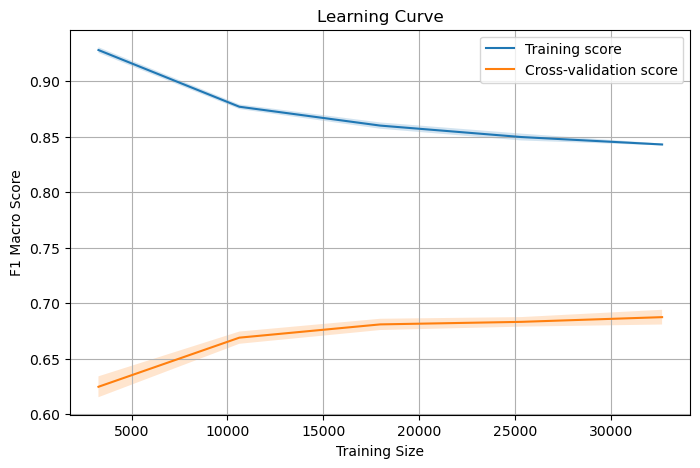

In [ ]:
# LEARNING CURVE
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    lr_best,             
    X_train,
    y_train,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True,
    random_state=13
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

train_std = np.std(train_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, val_mean, label="Cross-validation score")

plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2)

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("F1 Macro Score")
plt.legend()
plt.grid()
plt.show()

The learning curve shows the relationship between training set size and model performance. Training score starts high when the training size is small but decreases as the training size increases and stabilizes at around 0.85 F1 Macro Score as training size reaches 30,000 samples

Cross-validation score however starts at around 0.60 F1 Macro Score and graually increases as training size gets higher and stabilizes at around 0.70 F1 Macro Score as training size reaches 30,000 samples.

The curves show that the model generalises better and reduced overfitting as data increases and as the gap between Training and Cross-validation score gets closer.

## CITATIONS

1. GeeksforGeeks. (2024). Lemmatization vs Stemming. https://www.geeksforgeeks.org/nlp/lemmatization-vs-stemming/

2. GeeksforGeeks. (2021). Understanding TF-IDF (Term Frequency–Inverse Document Frequency). https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/

3. Pashu, N. (2024). Text preprocessing in NLP: Everything you need to know with code examples. Medium. https://medium.com/@natasha.pashu/text-preprocessing-in-nlp-everything-you-need-to-know-with-code-examples-7bb9ec4c7b77

4. DataToInfinity. (2025). Word cloud in NLP: A complete guide to visualizing text with Python. DEV Community. https://dev.to/datatoinfinity/word-cloud-in-nlp-a-complete-guide-to-visualizing-text-with-python-1m7l

5. Scikit-learn developers. (n.d.). sklearn.feature_extraction.text.TfidfVectorizer. https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

6. Scikit-learn developers. (n.d.). sklearn.linear_model.LogisticRegression. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

7. Scikit-learn developers. (n.d.). Support Vector Machines (SVM). https://scikit-learn.org/stable/api/sklearn.svm.html

8. Scikit-learn developers. (n.d.). sklearn.svm.LinearSVC. https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html

9. Scikit-learn developers. (n.d.). sklearn.naive_bayes.MultinomialNB. https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

10. GeeksforGeeks. (2023). F1 score in machine learning. https://www.geeksforgeeks.org/machine-learning/f1-score-in-machine-learning/

11. Number Analytics. (2025). F1 score for imbalanced classes: A guide. https://www.numberanalytics.com/blog/f1-score-imbalanced-classes-guide

12. MachineLearningMastery.com. (2023). A gentle introduction to k-fold cross-validation. https://machinelearningmastery.com/k-fold-cross-validation/

13. Wikipedia contributors. (2019). Learning curve (machine learning). https://en.wikipedia.org/wiki/Learning_curve_(machine_learning)

14. Sutranggono, A. N., Sarno, R., & Ghozali, I. (2024). Multi-class multi-level classification of mental health disorders based on textual data from social media. *Journal of Information and Communication Technology, 23*(1), 77–104. https://doi.org/10.32890/jict2024.23.1.4

15. Midhan, T. M., Selvaraj, P., Raju, M. H. V. K., Reddy, M. B. P., & Bhaskar, T. (2023). Classification of mental health and emotion of human from text using machine learning approaches. *2023 6th International Conference on Information Systems and Computer Networks (ISCON)*, 1–7. https://doi.org/10.1109/ISCON57294.2023.10111973

16. Remawati, D., Noersasongko, E., Marjuni, A., & Pujiono. (2024). Mental health detection with TF-IDF feature extraction. *2024 IEEE International Conference on Artificial Intelligence and Mechatronics Systems (AIMS)*, 1–6. https://doi.org/10.1109/AIMS61812.2024.10512480


